<a href="https://colab.research.google.com/github/Abdukamol0870/Avtomobil/blob/main/SI2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [95]:
# 2- amaliy topshiriq
# Mashinali o‘qitish turlari. Xatoliklarni hisoblash. Gradiyent
# pastlash algoritmlari. Chiziqli regressiya modeli qurish va baholash

In [96]:
import pandas as pd
from sklearn.model_selection import train_test_split

url = 'https://raw.githubusercontent.com/Abdukamol0870/avtomobil/main/Avto.csv'
df = pd.read_csv(url)

print(df.head(10))

X = df[['year']]
y = df['price']

X, X_test, y, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


     model  year  mileage  price
0  Nexia 2  2016   120000   8200
1  Nexia 2  2015   145000   7800
2  Nexia 2  2016    98000   8500
3  Nexia 2  2014   160000   7300
4  Nexia 2  2015   130000   7900
5  Nexia 2  2013   185000   6800
6  Nexia 2  2014   150000   7400
7  Nexia 2  2012   210000   6200
8  Nexia 2  2013   170000   6900
9  Nexia 2  2011   240000   5800


Mavjud modellar va ularning soni:

In [97]:
df['model'].value_counts()

,count
model,
Nexia 2,50


Chiziqli regressiya modelini yaratish:


In [98]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("model bashorati:")
print(y_pred)


model bashorati:
[4878.85762109 6348.52495031 6348.52495031 7818.19227953 8308.08138927
 6348.52495031 8308.08138927 4388.96851135 5368.74673083 7328.30316979]


In [99]:
nexia = df[df.model == 'Nexia 2']
nexia.head()
X= nexia['year']
y= nexia['price']

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

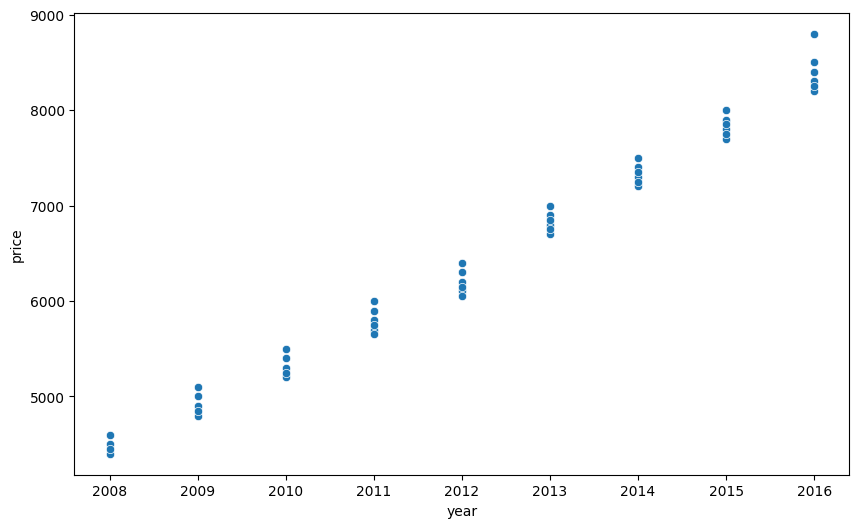

In [101]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=nexia, x='year', y='price')
plt.show()

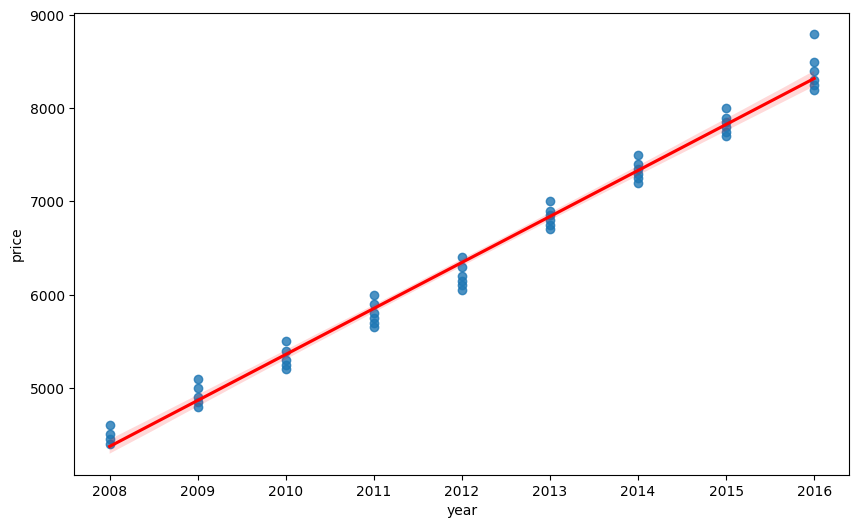

In [102]:
plt.figure(figsize=(10,6))
sns.regplot(data=nexia, x='year', y='price', line_kws = {"color":"red"})
plt.show()

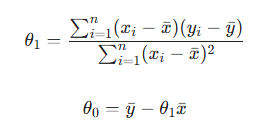

In [103]:
import numpy as np
X_mean = np.mean(X)
y_mean = np.mean(y)

In [104]:
theta1 = sum((X-X_mean)*(y-y_mean)) / sum((X-X_mean)**2)
print(f"{theta1=}")

theta1=493.51132789936463


In [105]:
theta0 = y_mean - theta1*X_mean
print(f"{theta0=}")

theta0=np.float64(-986599.1046787754)


In [106]:
x_test = nexia.sample(10, random_state=42)['year'].to_numpy()
print(f"{x_test=}")

y_test = nexia.sample(10, random_state=42)['price'].to_numpy()
print(f"{y_test=}")

x_test=array([2009, 2012, 2012, 2015, 2016, 2012, 2016, 2008, 2010, 2014])
y_test=array([4900, 6150, 6300, 7750, 8300, 6050, 8800, 4400, 5500, 7200])


In [107]:
y_predict = theta0 + theta1*x_test
print(f"{y_predict=}")

y_predict=array([4865.15307105, 6345.68705475, 6345.68705475, 7826.22103844,
       8319.73236634, 6345.68705475, 8319.73236634, 4371.64174315,
       5358.66439895, 7332.70971054])


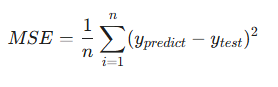
1. MSE (Mean Squared Error) — Modelning "Aybnomasi"

In [108]:
#MSE
farq = (y_predict - y_test)**2
mse = np.sum(farq)/len(y_test)
print(f"{mse=}")

mse=np.float64(40427.36962187616)


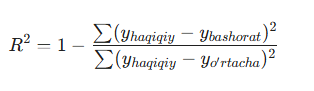

R² (R-squared) — Modelning "Bahosi" (Aniqlik darajasi)

In [118]:
y_ortacha = np.mean(y_test)

summa1 = np.sum((y_test - y_predict)**2)
summa2 = np.sum((y_test - y_ortacha)**2)

R2 = 1 - summa1/summa2
print(f"{R2=}")

R2=np.float64(0.9786157973992007)


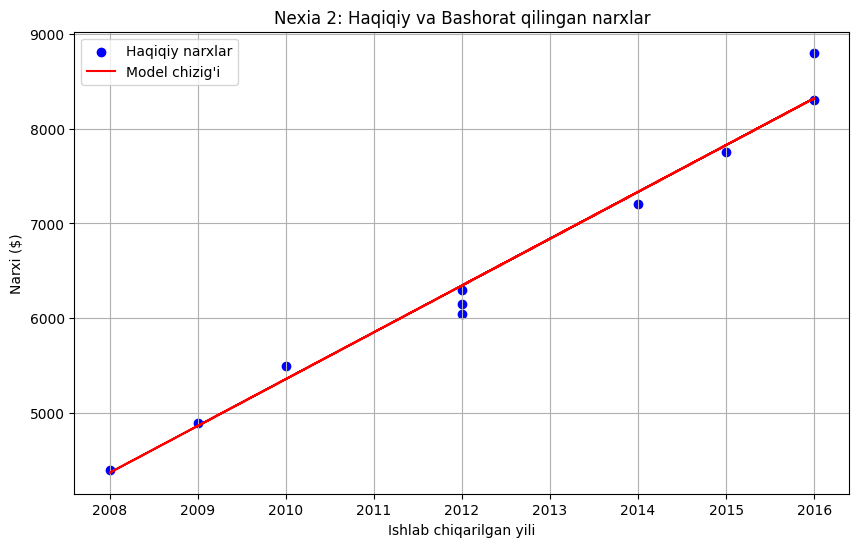

In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(X_test, y_test, color='blue', label='Haqiqiy narxlar')

plt.plot(X_test, y_predict, color='red', label='Model chizig\'i')

plt.title("Nexia 2: Haqiqiy va Bashorat qilingan narxlar")
plt.xlabel("Ishlab chiqarilgan yili")
plt.ylabel("Narxi ($)")
plt.legend()
plt.grid(True)

plt.show()